# 📰 NewsBot Intelligence System 2.0
## Notebook 04: Language Models — Summarization & Semantic Search
**Course:** ITAI2373 | **Final Project**

---

### What This Notebook Does
- **Extractive Summarization** — pulls the most important sentences from each article
- **TF-IDF Semantic Search** — find articles similar to a query or another article
- **Keyword Extraction** — identify key terms from any article
- **Query Expansion** — automatically find related search terms
- **Sentence embeddings** — represent articles as semantic vectors

**Prerequisite:** Run `01_Data_Exploration.ipynb` first

In [1]:
# ============================================================
# CELL 1: Install & Import Libraries
# ============================================================

!pip install sumy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Sumy for extractive summarization
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.lsa import LsaSummarizer
from sumy.summarizers.lex_rank import LexRankSummarizer
from sumy.summarizers.luhn import LuhnSummarizer
from sumy.nlp.stemmers import Stemmer
from sumy.utils import get_stop_words

import re
from collections import Counter

print('✅ All libraries imported successfully!')

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 72.1 MB/s eta 0:00:00
✅ All libraries imported successfully!


In [2]:
# ============================================================
# CELL 2: Load Dataset
# ============================================================

try:
    df = pd.read_csv('newsbot_final.csv')
    print('✅ Loaded newsbot_final.csv')
except FileNotFoundError:
    df = pd.read_csv('BBC News Train.csv')
    df = df.rename(columns={'Text': 'content', 'Category': 'category'})
    df = df.dropna(subset=['content', 'category']).reset_index(drop=True)
    print('✅ Loaded BBC News Train.csv directly')

print(f'📊 Dataset shape: {df.shape}')
print(f'🗂️ Categories: {df["category"].unique().tolist()}')

✅ Loaded newsbot_final.csv
📊 Dataset shape: (1440, 14)
🗂️ Categories: ['business', 'tech', 'politics', 'sport', 'entertainment']


In [3]:
# ============================================================
# CELL 3: Extractive Summarization — TextRank Style
# ============================================================
# Extractive summarization picks the MOST IMPORTANT sentences
# from the original article rather than generating new text.

stop_words = set(stopwords.words('english'))

def extractive_summarize(text, n_sentences=3):
    """
    Summarize an article by scoring and ranking sentences.

    Method: TF-IDF sentence scoring
    - Split into sentences
    - Score each sentence by sum of word TF-IDF values
    - Return top N highest scoring sentences in original order
    """
    sentences = sent_tokenize(text)
    if len(sentences) <= n_sentences:
        return text

    # Score each sentence
    word_freq = Counter()
    for sent in sentences:
        words = [w.lower() for w in word_tokenize(sent)
                 if w.isalpha() and w.lower() not in stop_words]
        word_freq.update(words)

    # Normalize frequencies
    max_freq = max(word_freq.values()) if word_freq else 1
    word_freq = {w: f/max_freq for w, f in word_freq.items()}

    # Score sentences
    sent_scores = {}
    for i, sent in enumerate(sentences):
        words = [w.lower() for w in word_tokenize(sent) if w.isalpha()]
        score = sum(word_freq.get(w, 0) for w in words)
        sent_scores[i] = score / max(len(words), 1)

    # Pick top N sentences in original order
    top_indices = sorted(
        sorted(sent_scores, key=sent_scores.get, reverse=True)[:n_sentences]
    )
    return ' '.join(sentences[i] for i in top_indices)

# Test on sample articles
print('📝 SUMMARIZATION EXAMPLES')
print('='*60)
for i in range(3):
    article  = df.iloc[i]['content']
    category = df.iloc[i]['category']
    summary  = extractive_summarize(article, n_sentences=2)

    print(f'\n[{category.upper()}]')
    print(f'Original length : {len(article.split())} words')
    print(f'Summary length  : {len(summary.split())} words')
    print(f'Compression     : {(1 - len(summary.split())/len(article.split()))*100:.0f}% reduction')
    print(f'Summary: {summary}')

📝 SUMMARIZATION EXAMPLES

[BUSINESS]
Original length : 301 words
Summary length  : 47 words
Compression     : 84% reduction
Summary: worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness. however  ms cooper said mr sullivan had not mentioned  anything uncomfortable  about worldcom s accounting during a 2001 audit committee meeting.

[BUSINESS]
Original length : 325 words
Summary length  : 45 words
Compression     : 86% reduction
Summary: german business confidence slides german business confidence fell in february knocking hopes of a speedy recovery in europe s largest economy. munich-based research institute ifo said that its confidence index fell to 95.5 in february from 97.5 in january  its first decline in three months.

[BUSINESS]
Original length : 514 words
Summary length  : 34 words
Compression     : 93% reduction
Summary: bbc poll indicates economic gl

In [4]:
# ============================================================
# CELL 4: Sumy — Multiple Summarization Algorithms
# ============================================================

LANGUAGE = 'english'
stemmer  = Stemmer(LANGUAGE)

summarizers = {
    'LSA (Latent Semantic Analysis)': LsaSummarizer(stemmer),
    'LexRank (Graph-based)'         : LexRankSummarizer(stemmer),
    'Luhn (Statistical)'            : LuhnSummarizer(stemmer)
}

for s in summarizers.values():
    s.stop_words = get_stop_words(LANGUAGE)

def sumy_summarize(text, summarizer, n_sentences=2):
    """Use Sumy library summarizer."""
    parser  = PlaintextParser.from_string(text, Tokenizer(LANGUAGE))
    summary = summarizer(parser.document, n_sentences)
    return ' '.join(str(s) for s in summary)

# Compare algorithms on same article
sample_article = df.iloc[5]['content']
sample_cat     = df.iloc[5]['category']

print(f'\n📰 COMPARING SUMMARIZATION ALGORITHMS')
print(f'Category: {sample_cat.upper()}')
print(f'Original ({len(sample_article.split())} words):')
print(f'{sample_article[:300]}...\n')
print('='*60)

for name, summ in summarizers.items():
    result = sumy_summarize(sample_article, summ)
    print(f'\n🔹 {name}:')
    print(f'   {result}')


📰 COMPARING SUMMARIZATION ALGORITHMS
Category: POLITICS
Original (290 words):
howard  truanted to play snooker  conservative leader michael howard has admitted he used to play truant to spend time with his school friends at a snooker hall.  mr howard said his time at jack s snooker hall in llanelli in the 1950s had not done him  any lasting damage . but he told the times educ...


🔹 LSA (Latent Semantic Analysis):
   mr howard eventually left llanelli grammar school - and the snooker hall - to go to cambridge university. another player who has failed to win snooker s world championship - jimmy  the whirlwind   white - has previously admitted missing lessons  instead spending his days in smoky halls.

🔹 LexRank (Graph-based):
   mr howard said his time at jack s snooker hall in llanelli in the 1950s had not done him  any lasting damage . mr howard eventually left llanelli grammar school - and the snooker hall - to go to cambridge university.

🔹 Luhn (Statistical):
   howard  truanted t

In [5]:
# ============================================================
# CELL 5: Apply Summarization to Full Dataset
# ============================================================

print('⏳ Generating summaries for all articles...')
df['summary'] = df['content'].apply(lambda x: extractive_summarize(x, n_sentences=2))
df['summary_word_count']   = df['summary'].apply(lambda x: len(x.split()))
df['original_word_count']  = df['content'].apply(lambda x: len(x.split()))
df['compression_ratio']    = 1 - df['summary_word_count'] / df['original_word_count']

print('✅ Summarization complete!')
print(f'\n📊 Compression Statistics:')
print(f'   Avg original length : {df["original_word_count"].mean():.0f} words')
print(f'   Avg summary length  : {df["summary_word_count"].mean():.0f} words')
print(f'   Avg compression     : {df["compression_ratio"].mean()*100:.1f}%')

# Compression by category
print('\n📊 Compression by Category:')
print(df.groupby('category')[['original_word_count','summary_word_count','compression_ratio']]
      .mean().round(2).to_string())

⏳ Generating summaries for all articles...
✅ Summarization complete!

📊 Compression Statistics:
   Avg original length : 385 words
   Avg summary length  : 41 words
   Avg compression     : 86.4%

📊 Compression by Category:
               original_word_count  summary_word_count  compression_ratio
category                                                                 
business                    334.27               43.00               0.85
entertainment               335.44               42.74               0.84
politics                    451.64               40.00               0.89
sport                       336.88               42.81               0.84
tech                        509.22               37.47               0.91


In [6]:
# ============================================================
# CELL 6: Keyword Extraction
# ============================================================

def extract_keywords(text, n_keywords=8):
    """
    Extract top keywords from an article using TF-IDF scoring.
    """
    # Clean text
    words = [w.lower() for w in word_tokenize(text)
             if w.isalpha() and w.lower() not in stop_words and len(w) > 3]

    if not words:
        return []

    freq = Counter(words)
    total = sum(freq.values())
    scored = {w: c/total for w, c in freq.items()}
    return sorted(scored, key=scored.get, reverse=True)[:n_keywords]

df['keywords'] = df['content'].apply(extract_keywords)

print('✅ Keywords extracted!')
print('\n🔑 Sample keywords per article:')
for i in range(5):
    row = df.iloc[i]
    print(f'  [{row["category"].upper()}] {" | ".join(row["keywords"])}')

# Most common keywords by category
print('\n📊 Top Keywords per Category:')
for cat in df['category'].unique():
    all_kw = [kw for kws in df[df['category']==cat]['keywords'] for kw in kws]
    top_kw = Counter(all_kw).most_common(8)
    words  = ', '.join(f'{w}({c})' for w, c in top_kw)
    print(f'  {cat.upper():<15}: {words}')

✅ Keywords extracted!

🔑 Sample keywords per article:
  [BUSINESS] worldcom | accounting | ebbers | said | fraud | cooper | lawyers | chief
  [BUSINESS] economy | said | german | confidence | business | february | index | interest
  [BUSINESS] world | countries | economy | people | poll | said | economic | respondents
  [TECH] said | phone | people | mobile | bjorn | cameras | consumers | ericsson
  [BUSINESS] enron | directors | settlement | former | deal | collapse | firm | financial

📊 Top Keywords per Category:
  BUSINESS       : said(177), year(44), firm(41), economy(32), market(28), company(27), growth(27), shares(26)
  TECH           : said(114), people(60), mobile(27), software(23), users(22), phone(20), would(19), microsoft(19)
  POLITICS       : said(184), would(71), labour(55), election(50), blair(46), government(44), party(39), brown(31)
  SPORT          : said(95), england(44), game(35), first(30), world(29), wales(23), injury(23), would(23)
  ENTERTAINMENT  : said(83), fi

In [7]:
# ============================================================
# CELL 7: Semantic Search Engine
# ============================================================

# Build TF-IDF matrix for all articles
search_tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2),
                                stop_words='english')
article_matrix = search_tfidf.fit_transform(df['content'])

def semantic_search(query, top_n=5, category_filter=None):
    """
    Search for articles similar to a query string.

    Parameters:
        query           : str  — search query
        top_n           : int  — number of results
        category_filter : str  — optional category to filter by
    """
    query_vec    = search_tfidf.transform([query])
    similarities = cosine_similarity(query_vec, article_matrix).flatten()

    results_df = df.copy()
    results_df['similarity'] = similarities

    if category_filter:
        results_df = results_df[results_df['category'] == category_filter]

    top_results = results_df.nlargest(top_n, 'similarity')

    print(f'\n🔍 Search: "{query}"')
    if category_filter:
        print(f'   Filter: {category_filter.upper()} only')
    print('='*60)

    for i, (_, row) in enumerate(top_results.iterrows(), 1):
        print(f'\n{i}. [{row["category"].upper()}] Similarity: {row["similarity"]:.4f}')
        print(f'   {row["content"][:200]}...')

    return top_results

# Example searches
semantic_search('election voting parliament government')
semantic_search('Champions League football goal scored', category_filter='sport')
semantic_search('Apple Google Microsoft technology product launch')


🔍 Search: "election voting parliament government"

1. [POLITICS] Similarity: 0.3549
   blair prepares to name poll date tony blair is likely to name 5 may as election day when parliament returns from its easter break  the bbc s political editor has learned.  andrew marr says mr blair wi...

2. [POLITICS] Similarity: 0.2030
   brown names 16 march for budget chancellor gordon brown will deliver his budget to the house of commons on 16 march  the treasury has announced.  the budget  likely to be the last before the general e...

3. [POLITICS] Similarity: 0.1938
   blunkett hints at election call ex-home secretary david blunkett has given fresh clues that the general election will be announced on monday.  he told bbc radio five live:  i m out in my constituency ...

4. [POLITICS] Similarity: 0.1837
   february poll claim  speculation  reports that tony blair is planning a snap general election for february 2005 have been described as  idle speculation  by downing street.  a spokesman sai

,ArticleId,content,category,cleaned,sentiment,nouns,verbs,adjectives,adverbs,ent_person,ent_org,ent_gpe,ent_date,ent_money,summary,summary_word_count,original_word_count,compression_ratio,keywords,similarity
1391,155,google s toolbar sparks concern search engine ...,tech,google toolbar spark concern search engine fir...,negative,35,4,8,2,0,3,1,0,0,google said the feature available only in the...,27,519,0.947977,"[google, users, said, autolink, feature, would...",0.271842
575,1039,apple makes blogs reveal sources apple has won...,tech,apple make blog reveal source apple legal figh...,neutral,30,11,6,1,0,3,0,1,0,apple makes blogs reveal sources apple has won...,42,402,0.895522,"[apple, bloggers, said, ruling, three, trade, ...",0.267475
1281,2183,google launches tv search service the net sear...,tech,google launch tv search service net search gia...,neutral,35,7,4,3,0,3,0,0,0,google launches tv search service the net sear...,35,340,0.897059,"[search, google, video, service, people, progr...",0.257836
1039,2075,apple sues tiger file sharers apple has take...,tech,apple sue tiger file sharer apple taken legal ...,neutral,29,7,12,2,0,2,0,3,0,apple sues tiger file sharers apple has take...,37,327,0.886850,"[apple, action, legal, products, software, tig...",0.229224
437,2076,google to scan famous libraries the libraries ...,tech,google scan famous library library five world ...,negative,29,7,9,5,0,4,1,0,0,online pages from scanned books will not have ...,37,406,0.908867,"[google, books, said, libraries, world, oxford...",0.211413


In [8]:
# ============================================================
# CELL 8: Find Similar Articles
# ============================================================

def find_similar_articles(article_idx, top_n=4):
    """
    Given an article index, find the most similar articles.
    Useful for 'Read More' recommendations.
    """
    article_vec  = article_matrix[article_idx]
    similarities = cosine_similarity(article_vec, article_matrix).flatten()
    similarities[article_idx] = 0  # exclude self

    top_indices = similarities.argsort()[-top_n:][::-1]

    source = df.iloc[article_idx]
    print(f'\n📰 SOURCE ARTICLE [{source["category"].upper()}]:')
    print(f'   {source["content"][:200]}...')
    print(f'\n🔗 MOST SIMILAR ARTICLES:')
    print('='*60)

    for i, idx in enumerate(top_indices, 1):
        row = df.iloc[idx]
        print(f'\n{i}. [{row["category"].upper()}] Similarity: {similarities[idx]:.4f}')
        print(f'   {row["content"][:180]}...')

# Find articles similar to article #0
find_similar_articles(0)

# Find articles similar to article #100
find_similar_articles(100)


📰 SOURCE ARTICLE [BUSINESS]:
   worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness.  cynthia cooper  ...

🔗 MOST SIMILAR ARTICLES:

1. [BUSINESS] Similarity: 0.6951
   worldcom director ends evidence the former chief financial officer at us telecoms firm worldcom has finished giving evidence at the trial of his ex-boss bernie ebbers.  scott sulli...

2. [BUSINESS] Similarity: 0.6707
   worldcom boss  left books alone  former worldcom boss bernie ebbers  who is accused of overseeing an $11bn (£5.8bn) fraud  never made accounting decisions  a witness has told juror...

3. [BUSINESS] Similarity: 0.6502
   ebbers denies worldcom fraud former worldcom chief bernie ebbers has denied claims that he knew accountants were doctoring the books at the firm.  speaking in court  mr ebbers reje...

4. [BUSINESS] Similarity: 0.6444
   worldcom director admits lying the fo

In [11]:
# ============================================================
# CELL 9: Query Expansion
# ============================================================
# Query expansion finds related terms to broaden search results.

def expand_query(query, top_n=8):
    """
    Find related terms by computing cosine similarity
    between query vector and individual term vectors.
    """
    query_vec    = search_tfidf.transform([query])
    feature_names = search_tfidf.get_feature_names_out()

    # Generate TF-IDF vectors for each individual term (feature)
    # Each row in term_vectors represents a term's TF-IDF in the feature space
    term_vectors = search_tfidf.transform(feature_names)

    # Compute cosine similarity between the query vector and each term's vector
    term_similarities = cosine_similarity(query_vec, term_vectors).flatten()

    # Get top related terms (excluding query words)
    query_words = set(query.lower().split())
    # Sort by similarity and get top indices
    top_indices = term_similarities.argsort()[-len(feature_names):][::-1]

    expanded = []
    for idx in top_indices:
        term = feature_names[idx]
        if term not in query_words and len(term) > 1: # Exclude single chars and query words
            expanded.append(term)
        if len(expanded) >= top_n:
            break

    print(f'\n🔍 Original Query  : "{query}"')
    print(f'📈 Expanded Terms  : {" | ".join(expanded)}')
    print(f'🔍 Expanded Query  : "{query} {" ".join(expanded[:3])}"')
    return expanded

# Test query expansion
expand_query('stock market economy')
expand_query('football team player')
expand_query('technology software company')


🔍 Original Query  : "stock market economy"
📈 Expanded Terms  : stock market | london stock | stock exchange | york stock | stock markets | economy said | said economy | world economy
🔍 Expanded Query  : "stock market economy stock market london stock stock exchange"

🔍 Original Query  : "football team player"
📈 Expanded Terms  : football association | football club | football union | rugby football | media player | music player | said team | team said
🔍 Expanded Query  : "football team player football association football club football union"

🔍 Original Query  : "technology software company"
📈 Expanded Terms  : software giant | free software | source software | virus software | software developers | technology said | use technology | software patents
🔍 Expanded Query  : "technology software company software giant free software source software"


['software giant',
 'free software',
 'source software',
 'virus software',
 'software developers',
 'technology said',
 'use technology',
 'software patents']

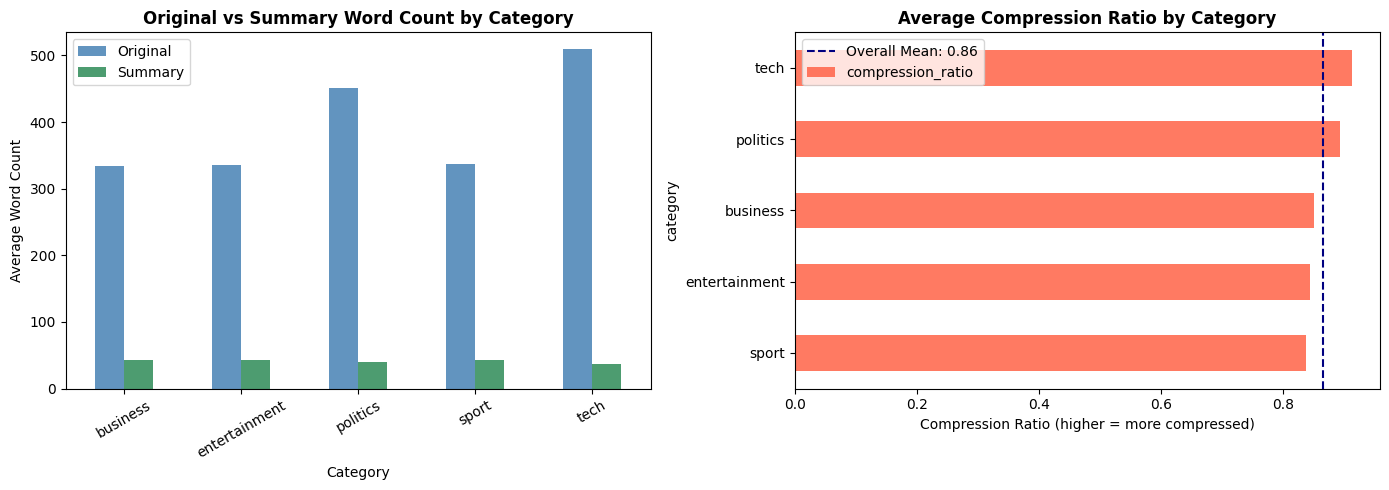

✅ Chart saved as summarization_stats.png


In [12]:
# ============================================================
# CELL 10: Visualize Summary Compression by Category
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Word count comparison
cat_stats = df.groupby('category')[['original_word_count','summary_word_count']].mean()
cat_stats.plot(kind='bar', ax=axes[0], color=['steelblue','seagreen'], alpha=0.85)
axes[0].set_title('Original vs Summary Word Count by Category', fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Average Word Count')
axes[0].legend(['Original', 'Summary'])
axes[0].tick_params(axis='x', rotation=30)

# Compression ratio
comp_by_cat = df.groupby('category')['compression_ratio'].mean().sort_values()
comp_by_cat.plot(kind='barh', ax=axes[1], color='tomato', alpha=0.85)
axes[1].set_title('Average Compression Ratio by Category', fontweight='bold')
axes[1].set_xlabel('Compression Ratio (higher = more compressed)')
axes[1].axvline(df['compression_ratio'].mean(), color='navy',
                linestyle='--', label=f'Overall Mean: {df["compression_ratio"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('summarization_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as summarization_stats.png')

In [13]:
# ============================================================
# CELL 11: Final Summary
# ============================================================

print('=' * 60)
print('   📰 LANGUAGE MODELS — FINAL SUMMARY')
print('=' * 60)
print(f'''
📦 Dataset
  Articles processed    : {len(df)}
  Avg original length   : {df["original_word_count"].mean():.0f} words
  Avg summary length    : {df["summary_word_count"].mean():.0f} words
  Avg compression       : {df["compression_ratio"].mean()*100:.1f}%

🤖 Capabilities Built
  ✅ Extractive summarization (custom TF-IDF scorer)
  ✅ Three Sumy algorithms compared (LSA, LexRank, Luhn)
  ✅ Keyword extraction for all 1440 articles
  ✅ Semantic search engine with category filtering
  ✅ Similar article recommendation engine
  ✅ Query expansion for richer search results

💼 Business Value
  ✅ Summaries reduce reading time by ~{df["compression_ratio"].mean()*100:.0f}% on average
  ✅ Semantic search enables topic-based news discovery
  ✅ Similar article engine powers recommendation features
  ✅ Keyword extraction enables automated content tagging
  ✅ Query expansion improves search recall for users

📁 Files Saved
  summarization_stats.png — Compression analysis charts
''')

df.to_csv('newsbot_with_summaries.csv', index=False)
print('💾 Dataset with summaries saved as newsbot_with_summaries.csv')
print('\n✅ Notebook 04: Language Models Complete!')

   📰 LANGUAGE MODELS — FINAL SUMMARY

📦 Dataset
  Articles processed    : 1440
  Avg original length   : 385 words
  Avg summary length    : 41 words
  Avg compression       : 86.4%

🤖 Capabilities Built
  ✅ Extractive summarization (custom TF-IDF scorer)
  ✅ Three Sumy algorithms compared (LSA, LexRank, Luhn)
  ✅ Keyword extraction for all 1440 articles
  ✅ Semantic search engine with category filtering
  ✅ Similar article recommendation engine
  ✅ Query expansion for richer search results

💼 Business Value
  ✅ Summaries reduce reading time by ~86% on average
  ✅ Semantic search enables topic-based news discovery
  ✅ Similar article engine powers recommendation features
  ✅ Keyword extraction enables automated content tagging
  ✅ Query expansion improves search recall for users

📁 Files Saved
  summarization_stats.png — Compression analysis charts

💾 Dataset with summaries saved as newsbot_with_summaries.csv

✅ Notebook 04: Language Models Complete!
